# Análisis multivariado de los 168 rezagos

PCA, correlaciones y anomalías sobre TRAIN de cada fold, por activo. El cálculo ejecutable está en `src/12_multivariate_close.py`. Por defecto se presentan las salidas guardadas; `RECALCULAR = True` repite los 25 diagnósticos. TEST permanece reservado.

In [1]:
from pathlib import Path
import runpy, json, hashlib
import pandas as pd
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p/'src/12_multivariate_close.py').is_file())
RECALCULAR = False
if RECALCULAR:
    runpy.run_path(str(ROOT/'src/12_multivariate_close.py'),run_name='__main__')
report=runpy.run_path(str(ROOT/'src/12_render_multivariate_report.py'))
report['render'](write_notebook=False)
meta=json.loads((ROOT/'outputs/tables/multivariate_metadata.json').read_text())
assert meta['hashes']['development']==hashlib.sha256((ROOT/'data/splits/development_80.csv').read_bytes()).hexdigest()
display(pd.read_csv(ROOT/'outputs/tables/multivariate_summary.csv'))
print('Ajustes: 25 PCA y 25 Isolation Forest; solo TRAIN. Filas eliminadas:',meta['rows_removed'])


Sección 2.4 y notebook sincronizados con los diagnósticos multivariados.


,symbol,fold,train_start,train_end,n,p,n_over_p,pc1_ratio,pc2_ratio,k90,...,numerical_rank,condition_number,median_abs_correlation,min_correlation,max_correlation,fraction_abs_correlation_gt_099,anomaly_threshold,flagged,flagged_pct,flagged_runs
0,BNBUSDT,1,2020-08-18 05:00:00+00:00,2021-06-03 20:00:00+00:00,5781,168,34.410714,0.985046,0.010327,1,...,168,1707.670657,0.988557,0.946543,0.999779,0.454092,0.629871,58,1.003287,17
1,BNBUSDT,2,2020-08-18 05:00:00+00:00,2022-03-28 10:00:00+00:00,12342,168,73.464286,0.988892,0.007049,1,...,168,1557.428998,0.990722,0.964407,0.999808,0.532720,0.639308,124,1.004699,2
2,BNBUSDT,3,2020-08-18 05:00:00+00:00,2023-01-20 00:00:00+00:00,19484,168,115.976190,0.987662,0.007822,1,...,168,1382.582677,0.989706,0.960480,0.999780,0.491018,0.643753,195,1.000821,7
3,BNBUSDT,4,2020-08-18 05:00:00+00:00,2023-11-13 14:00:00+00:00,26433,168,157.339286,0.987568,0.007864,1,...,168,1354.411319,0.989603,0.960227,0.999776,0.485173,0.656778,265,1.002535,21
4,BNBUSDT,5,2020-08-18 05:00:00+00:00,2024-09-06 04:00:00+00:00,33575,168,199.851190,0.989626,0.006571,1,...,168,1469.383319,0.991305,0.967256,0.999812,0.556886,0.643124,336,1.000745,10
5,BTCUSDT,1,2020-08-18 05:00:00+00:00,2021-06-03 20:00:00+00:00,5781,168,34.410714,0.991888,0.004740,1,...,168,1723.356944,0.992866,0.974338,0.999823,0.653122,0.593805,58,1.003287,8
6,BTCUSDT,2,2020-08-18 05:00:00+00:00,2022-03-28 10:00:00+00:00,12342,168,73.464286,0.989107,0.006236,1,...,168,1364.358628,0.990007,0.967630,0.999783,0.500143,0.607989,124,1.004699,14
7,BTCUSDT,3,2020-08-18 05:00:00+00:00,2023-01-20 00:00:00+00:00,19484,168,115.976190,0.991116,0.005216,1,...,168,1519.202336,0.991991,0.972998,0.999827,0.606074,0.609433,195,1.000821,6
8,BTCUSDT,4,2020-08-18 05:00:00+00:00,2023-11-13 14:00:00+00:00,26433,168,157.339286,0.990845,0.005427,1,...,168,1502.837668,0.991784,0.971993,0.999825,0.592957,0.623832,265,1.002535,5
9,BTCUSDT,5,2020-08-18 05:00:00+00:00,2024-09-06 04:00:00+00:00,33575,168,199.851190,0.993042,0.004173,1,...,168,1699.266444,0.993829,0.978797,0.999867,0.729969,0.606777,336,1.000745,14


Ajustes: 25 PCA y 25 Isolation Forest; solo TRAIN. Filas eliminadas: False


## 2.4 Análisis multivariado de los 168 rezagos

### 2.4.1 Matriz real y alcance temporal

El modelo utiliza una variable de origen (`close`), pero **168 predictores distintos**: $X_{i,s}=(C_{i,s},C_{i,s-1},\ldots,C_{i,s-167})$. Por ello, la matriz sí requiere análisis multivariado. Se estudia cada activo por separado; no se mezclan precios nominales de criptomonedas distintas ni se incluyen `symbol`, timestamps, el objetivo futuro o Persistence como columnas del análisis.

Se reproducen exactamente las anclas de TRAIN de los cinco folds de la sección 3, incluida la intersección de elegibilidad entre activos y el confinamiento de historias y etiquetas al bloque. La elegibilidad verifica que el objetivo exista, pero **su valor no se utiliza para ajustar PCA, el escalador ni el detector de anomalías**. Cada ajuste usa solamente su TRAIN; no se ajusta ni se elige nada con VALIDATION o TEST. Los TRAIN son crecientes y se solapan entre folds; sus resultados no representan 25 muestras independientes.

| Fold | Inicio anclas TRAIN UTC | Fin anclas TRAIN UTC | n por activo | p | n/p |
| --- | --- | --- | --- | --- | --- |
| 1 | 2020-08-18 05:00 | 2021-06-03 20:00 | 5781 | 168 | 34.41 |
| 2 | 2020-08-18 05:00 | 2022-03-28 10:00 | 12342 | 168 | 73.46 |
| 3 | 2020-08-18 05:00 | 2023-01-20 00:00 | 19484 | 168 | 115.98 |
| 4 | 2020-08-18 05:00 | 2023-11-13 14:00 | 26433 | 168 | 157.34 |
| 5 | 2020-08-18 05:00 | 2024-09-06 04:00 | 33575 | 168 | 199.85 |

La relación n/p describe filas por predictor, no observaciones estadísticamente independientes. Dos ventanas contiguas comparten 167 cierres. Se conservan los huecos del calendario, sin imputación ni eliminación de valores extremos. Los paneles detallados muestran TRAIN del fold 5 y las tablas de estabilidad comparan los cinco TRAIN.

### 2.4.2 Redundancia, rango y correlación

Se estandarizan las 168 columnas con `StandardScaler` ajustado de nuevo en cada TRAIN y activo. Se calcula su matriz de Pearson. Se informa la mediana del valor absoluto de las 14.028 correlaciones fuera de la diagonal y la proporción con $|r|>0.99$; ese umbral es descriptivo, no una regla de selección.

La SVD de la matriz estandarizada y centrada permite distinguir rango numérico y redundancia: el rango cuenta los valores singulares mayores que $\max(n,p)\,\epsilon_{\mathrm{mach}}\,s_{max}$, donde $\epsilon_{\mathrm{mach}}$ es la precisión de máquina. El número de condición es $\kappa=s_{max}/s_{min}$ cuando el rango es completo. Un número elevado señala direcciones con escalas de variación muy distintas; no prueba fuga ni determina automáticamente qué rezagos eliminar. El VIF de los candidatos de 2.3 se complementa aquí con el espectro de la matriz completa, en lugar de añadir 168 regresiones auxiliares. Para anomalías se utiliza Isolation Forest, que no requiere invertir la covarianza como la distancia de Mahalanobis convencional.

| Activo · TRAIN fold 5 | Mediana \|r\| | Pares con \|r\| > 0.99 (%) | Rango numérico | Número de condición |
| --- | --- | --- | --- | --- |
| BNBUSDT | 0.99130 | 55.69 | 168 | 1469.4 |
| BTCUSDT | 0.99383 | 73.00 | 168 | 1699.3 |
| ETHUSDT | 0.99054 | 52.45 | 168 | 1434.7 |
| SOLUSDT | 0.99352 | 68.76 | 168 | 1724.9 |
| XRPUSDT | 0.97949 | 24.52 | 168 | 965.2 |

Las altas asociaciones entre niveles de precio rezagados pueden reflejar persistencia, tendencia y mezcla de periodos. La estandarización no elimina esa estructura ni vuelve estacionarias las series. La redundancia ayuda a explicar por qué los coeficientes individuales del SVR deben interpretarse con cautela.

### 2.4.3 PCA y dimensión efectiva

Se ejecuta [PCA de scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) con SVD completa (`svd_solver="full"`) sobre cada matriz estandarizada de TRAIN. PCA centra las columnas; el escalado se realiza explícitamente antes. Se conservan los 168 componentes para diagnosticar el espectro, sin introducir PCA en el SVR ni seleccionar variables a partir del resultado.

Se reporta el mínimo número de componentes para alcanzar 90 %, 95 % y 99 % de la varianza, con umbrales fijados en el protocolo antes del cálculo. Además, con $q_j=\lambda_j/\sum_k\lambda_k$, la dimensión efectiva por entropía es:

$$
d_{efectiva}=\exp\left(-\sum_{j:q_j>0}q_j\ln q_j\right).
$$

Esta dimensión continua resume la concentración del espectro y no equivale al rango numérico ni a un número óptimo de predictores para pronosticar.

| Activo · TRAIN fold 5 | PC1 (%) | PC2 (%) | k90 | k95 | k99 | Dimensión efectiva |
| --- | --- | --- | --- | --- | --- | --- |
| BNBUSDT | 98.963 | 0.657 | 1 | 1 | 2 | 1.077 |
| BTCUSDT | 99.304 | 0.417 | 1 | 1 | 1 | 1.055 |
| ETHUSDT | 98.906 | 0.679 | 1 | 1 | 2 | 1.081 |
| SOLUSDT | 99.237 | 0.472 | 1 | 1 | 1 | 1.059 |
| XRPUSDT | 97.656 | 1.415 | 1 | 1 | 2 | 1.162 |

En TRAIN del fold 5, PC1 concentra entre 97.656% y 99.304% de la varianza estandarizada. Para alcanzar 95 % se requieren entre 1 y 1 componentes; para 99 %, entre 1 y 2. La dimensión efectiva varía entre 1.055 y 1.162, mientras que el rango numérico se informa separadamente.

La alineación absoluta de PC1 con el vector uniforme $\mathbf{1}/\sqrt{168}$ permite examinar si el primer componente representa principalmente el nivel conjunto de los cierres. Los pesos de PC1 y PC2 se grafican por rezago. El signo de un componente es arbitrario; para dibujarlo se orienta hacia suma de pesos no negativa, sin cambiar la varianza explicada.

| Activo | \|coseno(PC1, nivel uniforme)\| |
| --- | --- |
| BNBUSDT | 0.999997 |
| BTCUSDT | 0.999999 |
| ETHUSDT | 0.999997 |
| SOLUSDT | 0.999998 |
| XRPUSDT | 0.999985 |

La alineación mínima observada es 0.999985. La cercanía a uno respalda interpretar PC1 principalmente como un movimiento conjunto de nivel en estos entrenamientos, no como una medida de volatilidad futura.

**Explicar varianza de precios no equivale a explicar volatilidad futura.** Las direcciones de baja varianza pueden contener información predictiva. No se interpreta un PC1 dominante como evidencia de que un único componente baste para el pronóstico ni como razón para cambiar ahora el modelo base.

### 2.4.4 Estabilidad descriptiva entre entrenamientos

| Activo | PC1 mín.–máx. (%) | k95 mín.–máx. | k99 mín.–máx. | Dimensión efectiva mín.–máx. |
| --- | --- | --- | --- | --- |
| BNBUSDT | 98.505–98.963 | 1–1 | 2–2 | 1.077–1.103 |
| BTCUSDT | 98.911–99.304 | 1–1 | 1–2 | 1.055–1.082 |
| ETHUSDT | 98.453–98.944 | 1–1 | 2–2 | 1.079–1.109 |
| SOLUSDT | 98.499–99.237 | 1–1 | 1–2 | 1.059–1.114 |
| XRPUSDT | 96.755–97.803 | 1–1 | 2–3 | 1.152–1.213 |

Los rangos resumen los cinco TRAIN crecientes por activo. No son intervalos de confianza y no permiten una prueba de estabilidad independiente: los folds comparten historia y al ampliarlos cambian los periodos y regímenes representados. Cada PCA tiene su propia base; las coordenadas de componentes de distintos ajustes no se comparan directamente como si compartieran orientación.

### 2.4.5 Anomalías multivariadas

Se ajusta [Isolation Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html) directamente sobre las **168 columnas estandarizadas**, sin reducirlas antes mediante PCA. Se fijan 200 árboles, submuestras de 256 ventanas, todas las columnas disponibles, `contamination="auto"`, semilla 42 y ejecución secuencial. El puntaje usado es $a(X)=-\operatorname{score\_samples}(X)$: valores mayores representan mayor atipicidad según el detector.

La señalización utiliza un umbral propio y explícito: percentil 99 de los puntajes del mismo TRAIN, con desigualdad estricta `score > umbral`. No se utiliza el umbral automático de `predict`. El percentil se fija como criterio descriptivo antes de observar los resultados; no es una probabilidad de error ni una tasa de falsos positivos calibrada. Señalar aproximadamente el 1 % de TRAIN es una consecuencia de esa regla, no un descubrimiento de que el 1 % de los datos sea erróneo.

| Activo · TRAIN fold 5 | Umbral TRAIN | Anclas señaladas | Porcentaje | Secuencias consecutivas |
| --- | --- | --- | --- | --- |
| BNBUSDT | 0.64312 | 336 | 1.001 | 10 |
| BTCUSDT | 0.60678 | 336 | 1.001 | 14 |
| ETHUSDT | 0.65635 | 336 | 1.001 | 14 |
| SOLUSDT | 0.67656 | 336 | 1.001 | 1 |
| XRPUSDT | 0.71600 | 336 | 1.001 | 6 |

Se agrupan anclas señaladas consecutivas separadas exactamente por una hora en secuencias descriptivas. Los huecos interrumpen las secuencias. Estas secuencias no identifican eventos económicos independientes: las ventanas se solapan y dos secuencias pueden compartir cierres.

| Activo | Inicio secuencia UTC | Fin secuencia UTC | Anclas | Puntaje máximo |
| --- | --- | --- | --- | --- |
| BNBUSDT | 2024-06-07 11:00 | 2024-06-13 20:00 | 154 | 0.70798 |
| BTCUSDT | 2024-03-14 14:00 | 2024-03-18 23:00 | 106 | 0.63051 |
| ETHUSDT | 2021-11-07 22:00 | 2021-11-19 04:00 | 271 | 0.71224 |
| SOLUSDT | 2021-11-06 11:00 | 2021-11-20 10:00 | 336 | 0.74273 |
| XRPUSDT | 2021-04-16 06:00 | 2021-04-19 01:00 | 68 | 0.75560 |

La tabla localiza, por activo, la secuencia que contiene el puntaje máximo de TRAIN del fold 5. No atribuye causas a las fechas. Los precios de nivel extremo, las transiciones de nivel o las trayectorias poco habituales pueden generar puntuaciones altas sin ser errores de cotización. Las ventanas señaladas se conservan; no se recortan ni se reentrena el SVR para mejorar métricas después de observarlas.

| Activo | 2020 (% señalado) | 2021 (% señalado) | 2022 (% señalado) | 2023 (% señalado) | 2024 (% señalado) |
| --- | --- | --- | --- | --- | --- |
| BNBUSDT | 0.00 | 2.41 | 0.00 | 0.00 | 2.61 |
| BTCUSDT | 5.66 | 0.00 | 0.00 | 0.00 | 2.98 |
| ETHUSDT | 0.00 | 4.49 | 0.00 | 0.00 | 0.00 |
| SOLUSDT | 0.00 | 4.49 | 0.00 | 0.00 | 0.00 |
| XRPUSDT | 0.00 | 4.49 | 0.00 | 0.00 | 0.00 |

Los porcentajes anuales usan como denominador las anclas elegibles de cada año, con extremos parciales. Se calculan con un único detector ajustado sobre todo TRAIN del fold 5. Son una descripción retrospectiva, no detección en línea disponible en cada fecha histórica ni evidencia de deterioro futuro. Los puntajes tampoco están calibrados para comparar riesgo entre activos.

### 2.4.6 Estructura, subpoblaciones y gráficos

Los activos son grupos conocidos, tratados por separado. Las proyecciones PC1–PC2 se colorean por año UTC para examinar cómo se distribuyen los periodos en la representación. Solo para esa visualización se muestran hasta 5.000 anclas uniformemente espaciadas en orden temporal; PCA, correlaciones y anomalías utilizan todas las filas elegibles de TRAIN. Los gráficos por activo tienen bases propias y no permiten comparar directamente coordenadas entre criptomonedas.

Las matrices de correlación y las curvas de varianza acumulada muestran escalas ampliadas, identificadas en sus ejes, para hacer visible la redundancia sin ocultar las diferencias entre rezagos. No parten necesariamente de cero; los valores completos se conservan en las tablas y matrices numéricas.

La distribución temporal en la proyección puede reflejar niveles de precio y cambios de escala, sin demostrar clusters o regímenes discretos. No se ejecuta clustering, UMAP ni t-SNE: el objetivo de esta sección es caracterizar la matriz real, no elegir un número de regímenes sin un criterio temporal de estabilidad. El clustering de regímenes exigiría una representación pertinente, validación de estabilidad y una pregunta adicional; no se declaran grupos descubiertos a partir de estos gráficos.











### 2.4.7 Consecuencias y reproducibilidad

El análisis establece la dimensión nominal, la concentración de varianza, la redundancia y la atipicidad conjunta de la entrada utilizada. Motiva estudiar, en un experimento posterior, representaciones de retornos o reducción de dimensionalidad; no prueba que mejoren el pronóstico. Cualquier uso predictivo de PCA, selección de componentes o tratamiento de anomalías deberá ajustarse dentro del entrenamiento y elegirse con validación temporal, conservando TEST reservado. Los resultados del SVR y Persistence permanecen intactos.

El protocolo previo está en `outputs/tables/multivariate_protocol.json`. El cálculo está en `src/12_multivariate_close.py`; `src/12_render_multivariate_report.py` sincroniza informe y notebook. Se guardan los 25 resúmenes, el espectro completo, parámetros de escalado, matrices de correlación, pesos de PC1/PC2, puntajes del fold 5 y secuencias señaladas en `outputs/tables/multivariate_*`. Los metadatos registran semillas, versiones, huellas y alcance de ajuste. Las pruebas verifican dimensiones conocidas, rechazo de la etiqueta como entrada y las fronteras temporales compartidas con el modelo.

Para reproducir: `python -m unittest discover -s tests -v`, `python src/12_multivariate_close.py` y `python src/12_render_multivariate_report.py`. El notebook carga los resultados verificados por defecto; `RECALCULAR = True` repite los 25 diagnósticos.

[Notebook multivariado con resultados ejecutados](./12_multivariate_scope_close.ipynb).



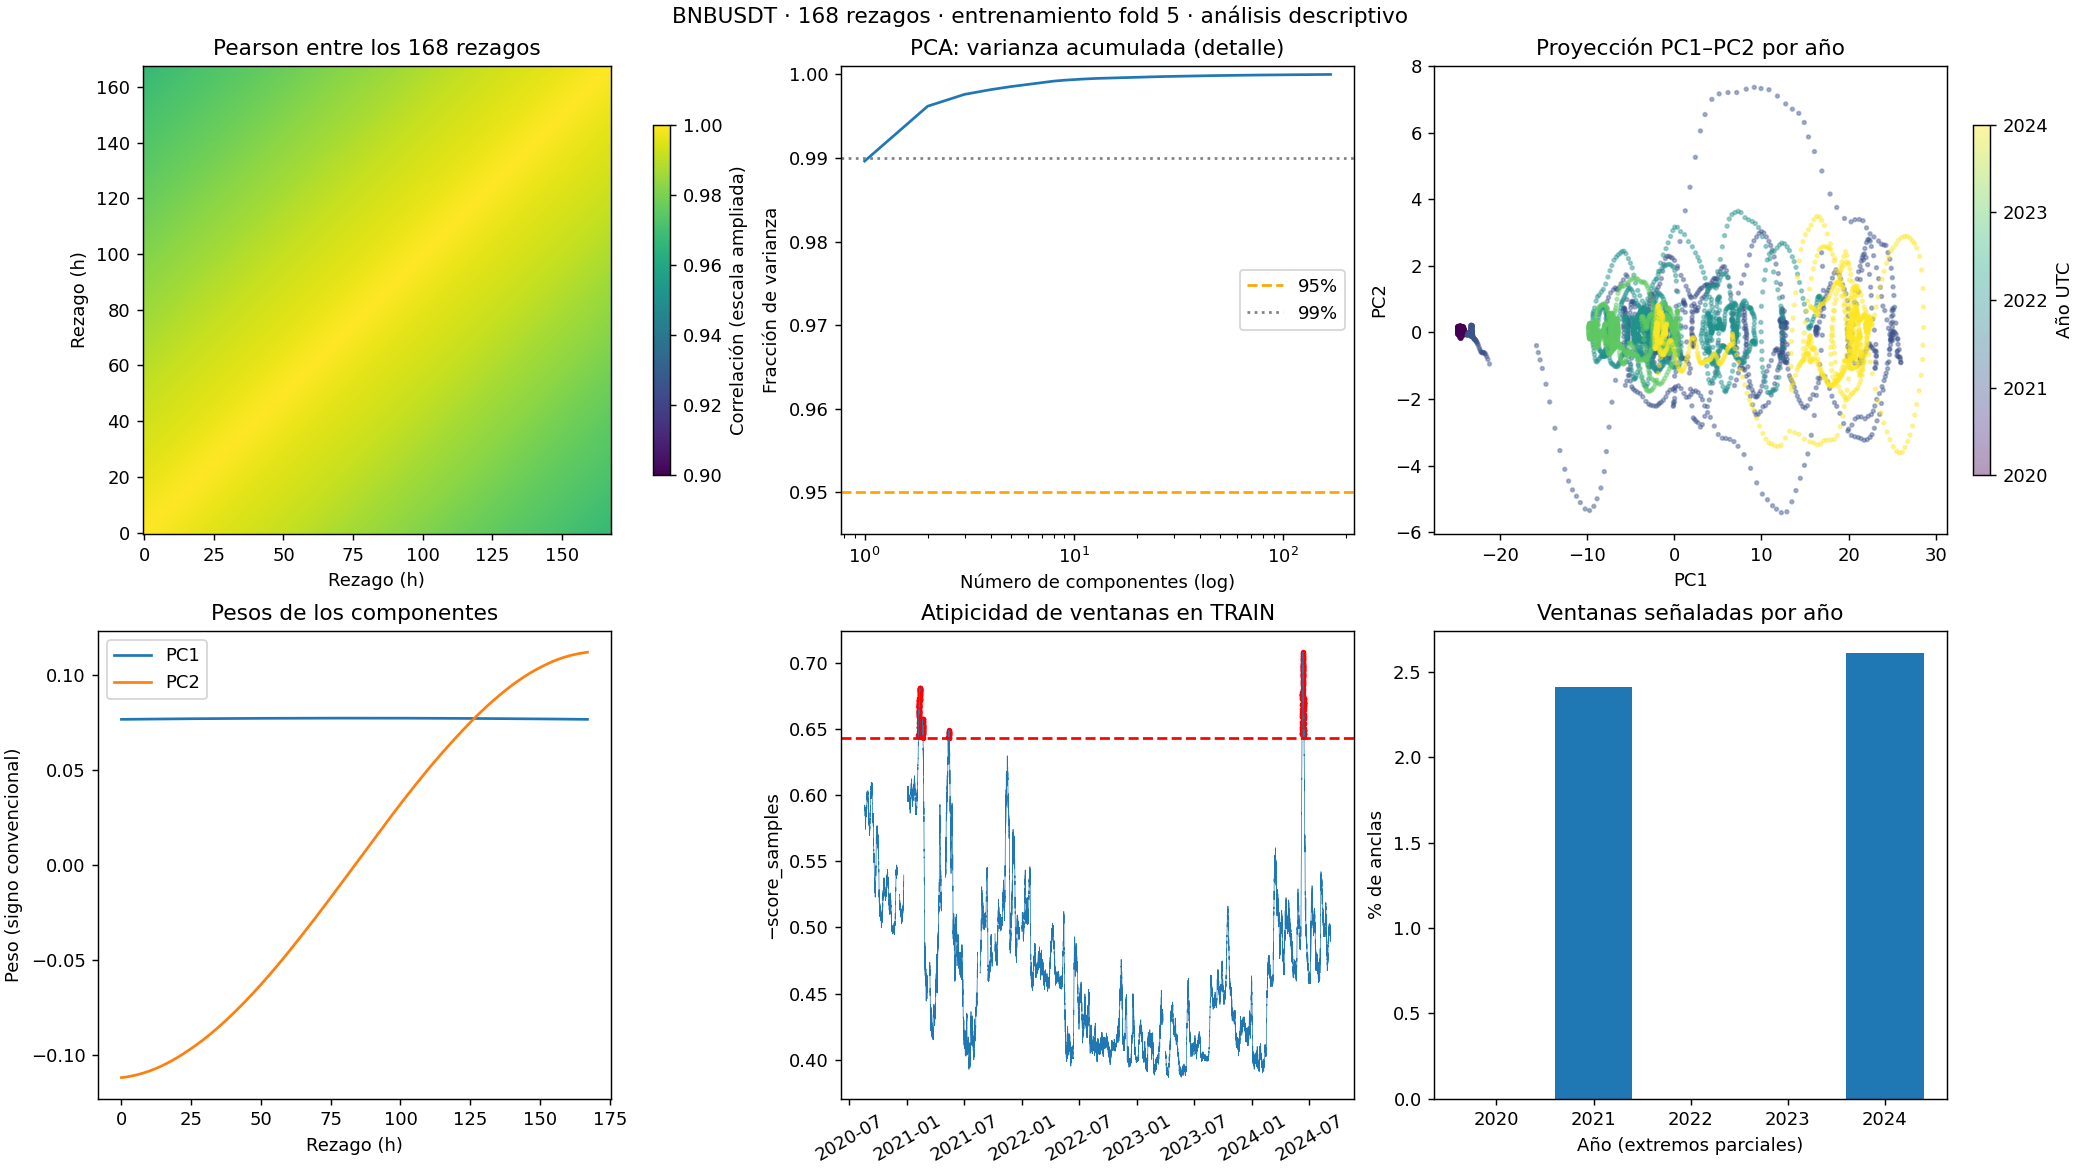

In [2]:
display(Image(filename=str(ROOT/'book/_static/figures/multivariate_BNBUSDT.png')))

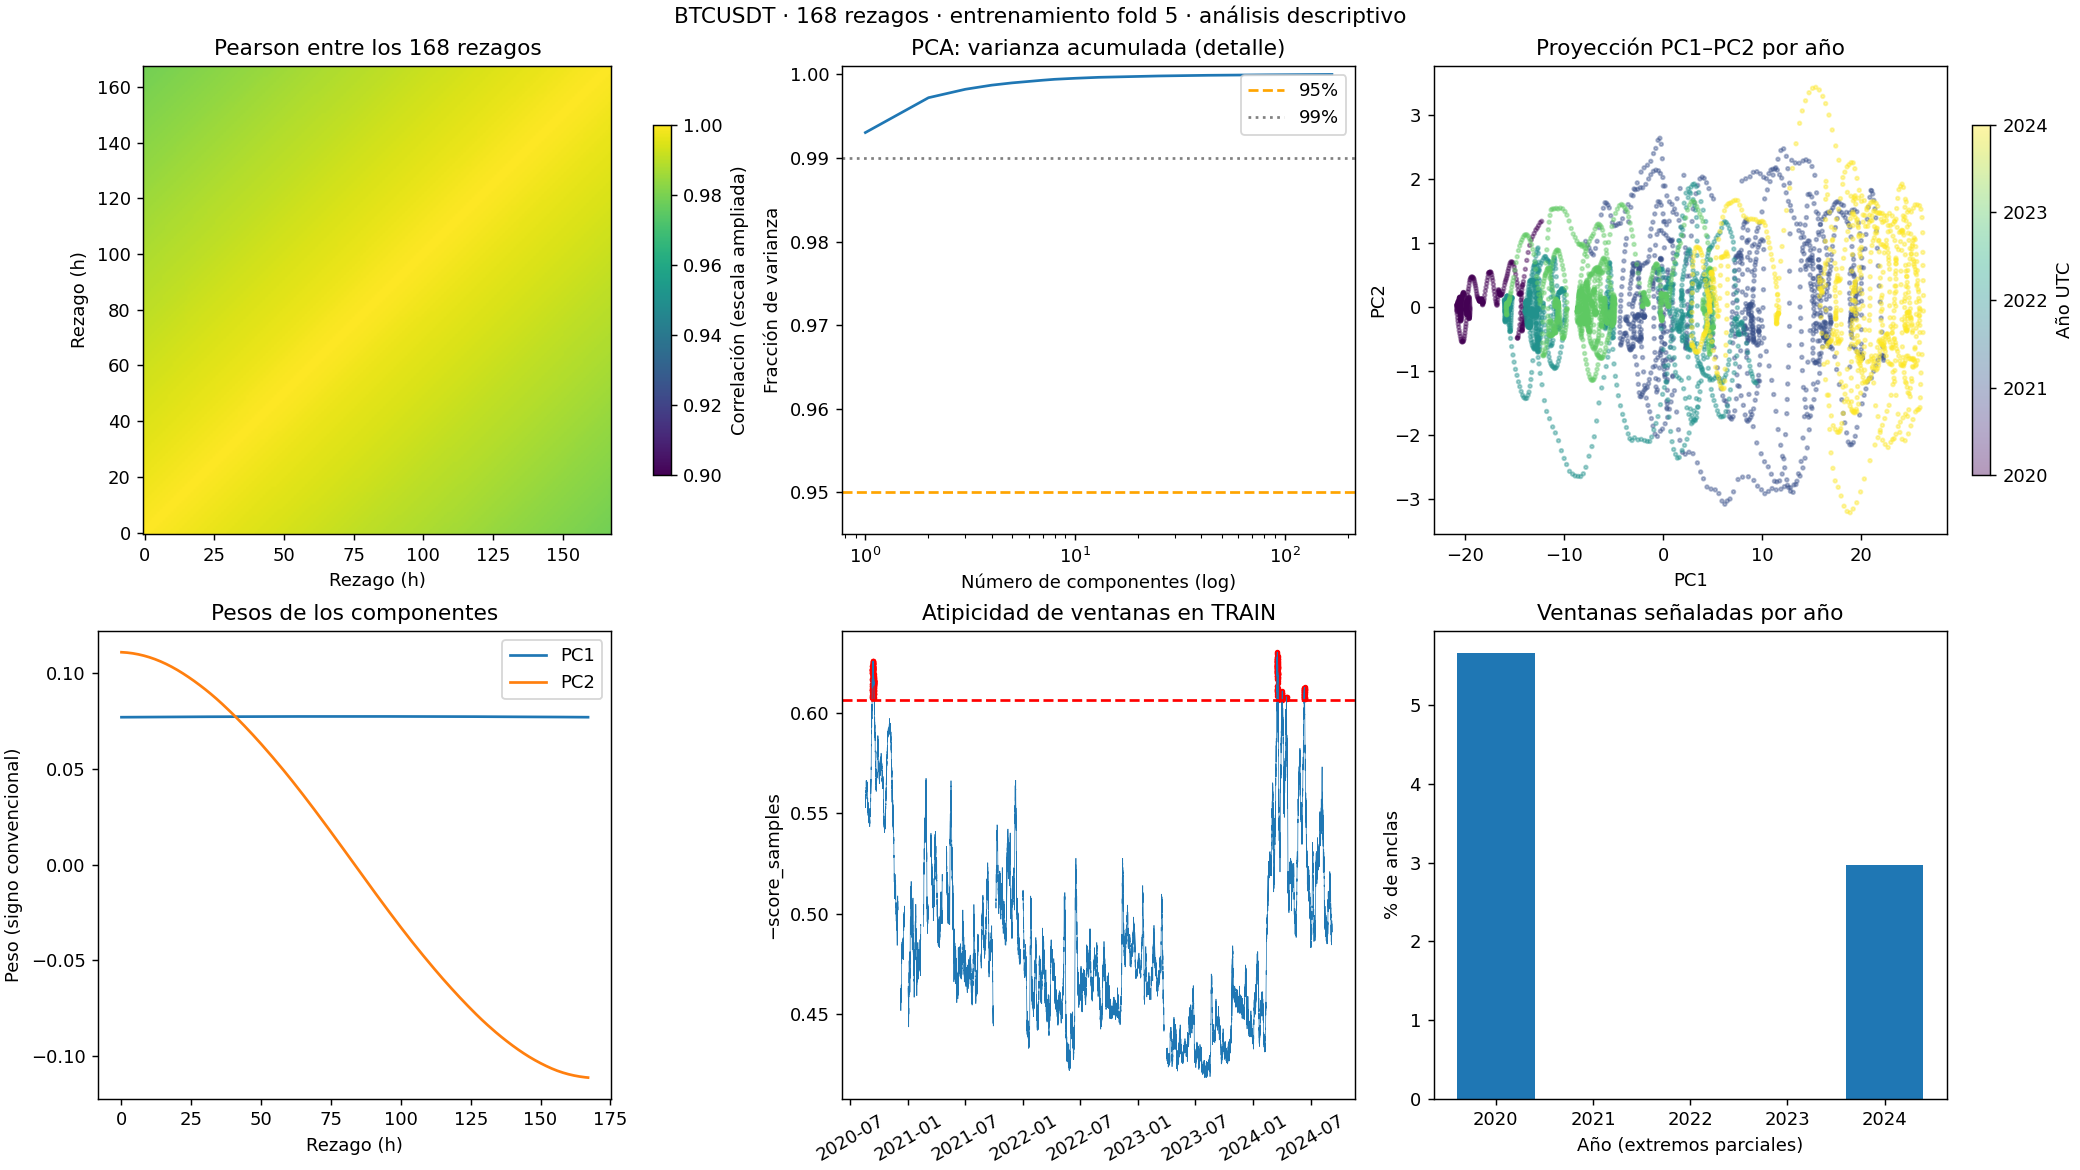

In [3]:
display(Image(filename=str(ROOT/'book/_static/figures/multivariate_BTCUSDT.png')))

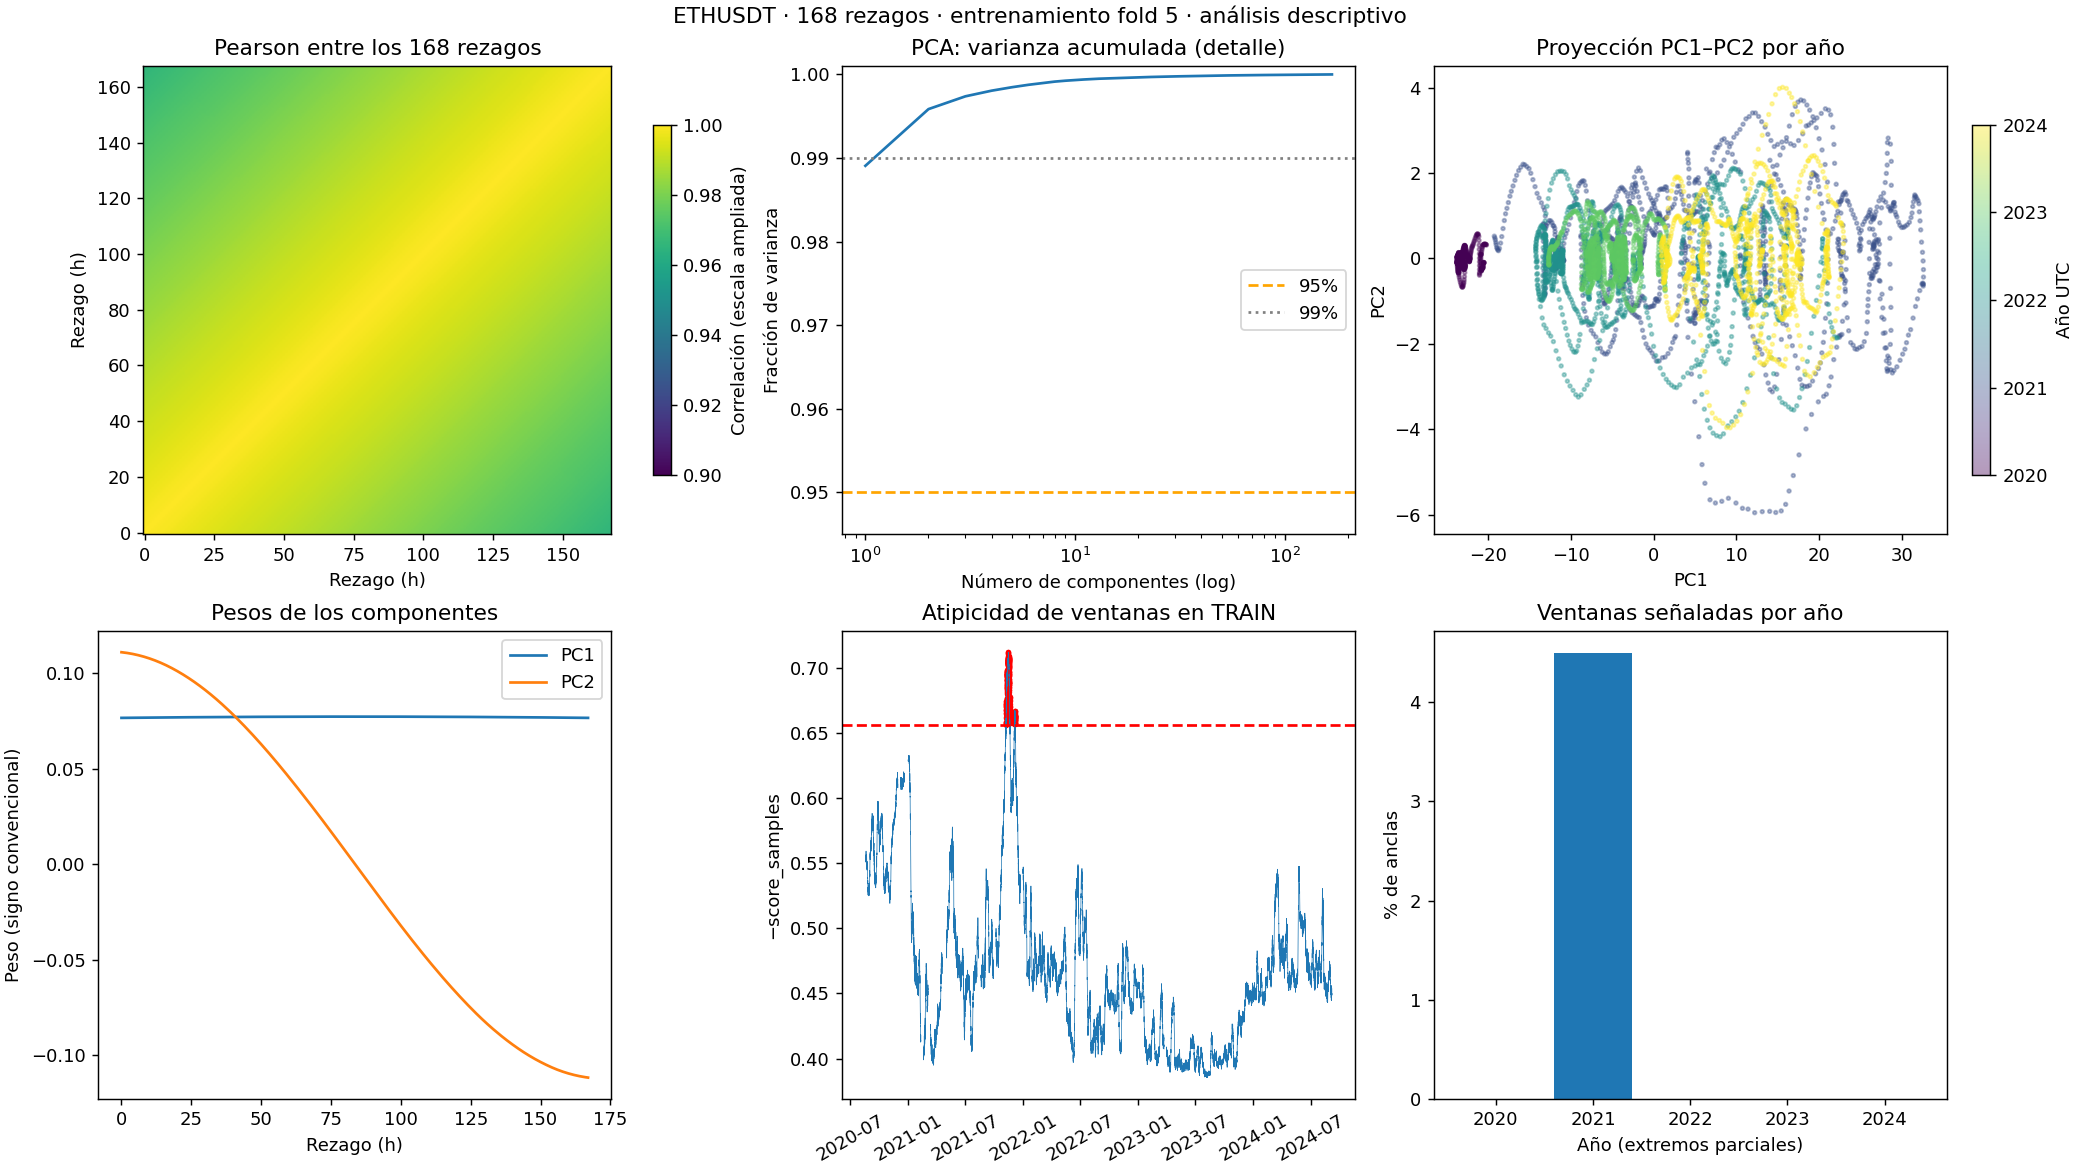

In [4]:
display(Image(filename=str(ROOT/'book/_static/figures/multivariate_ETHUSDT.png')))

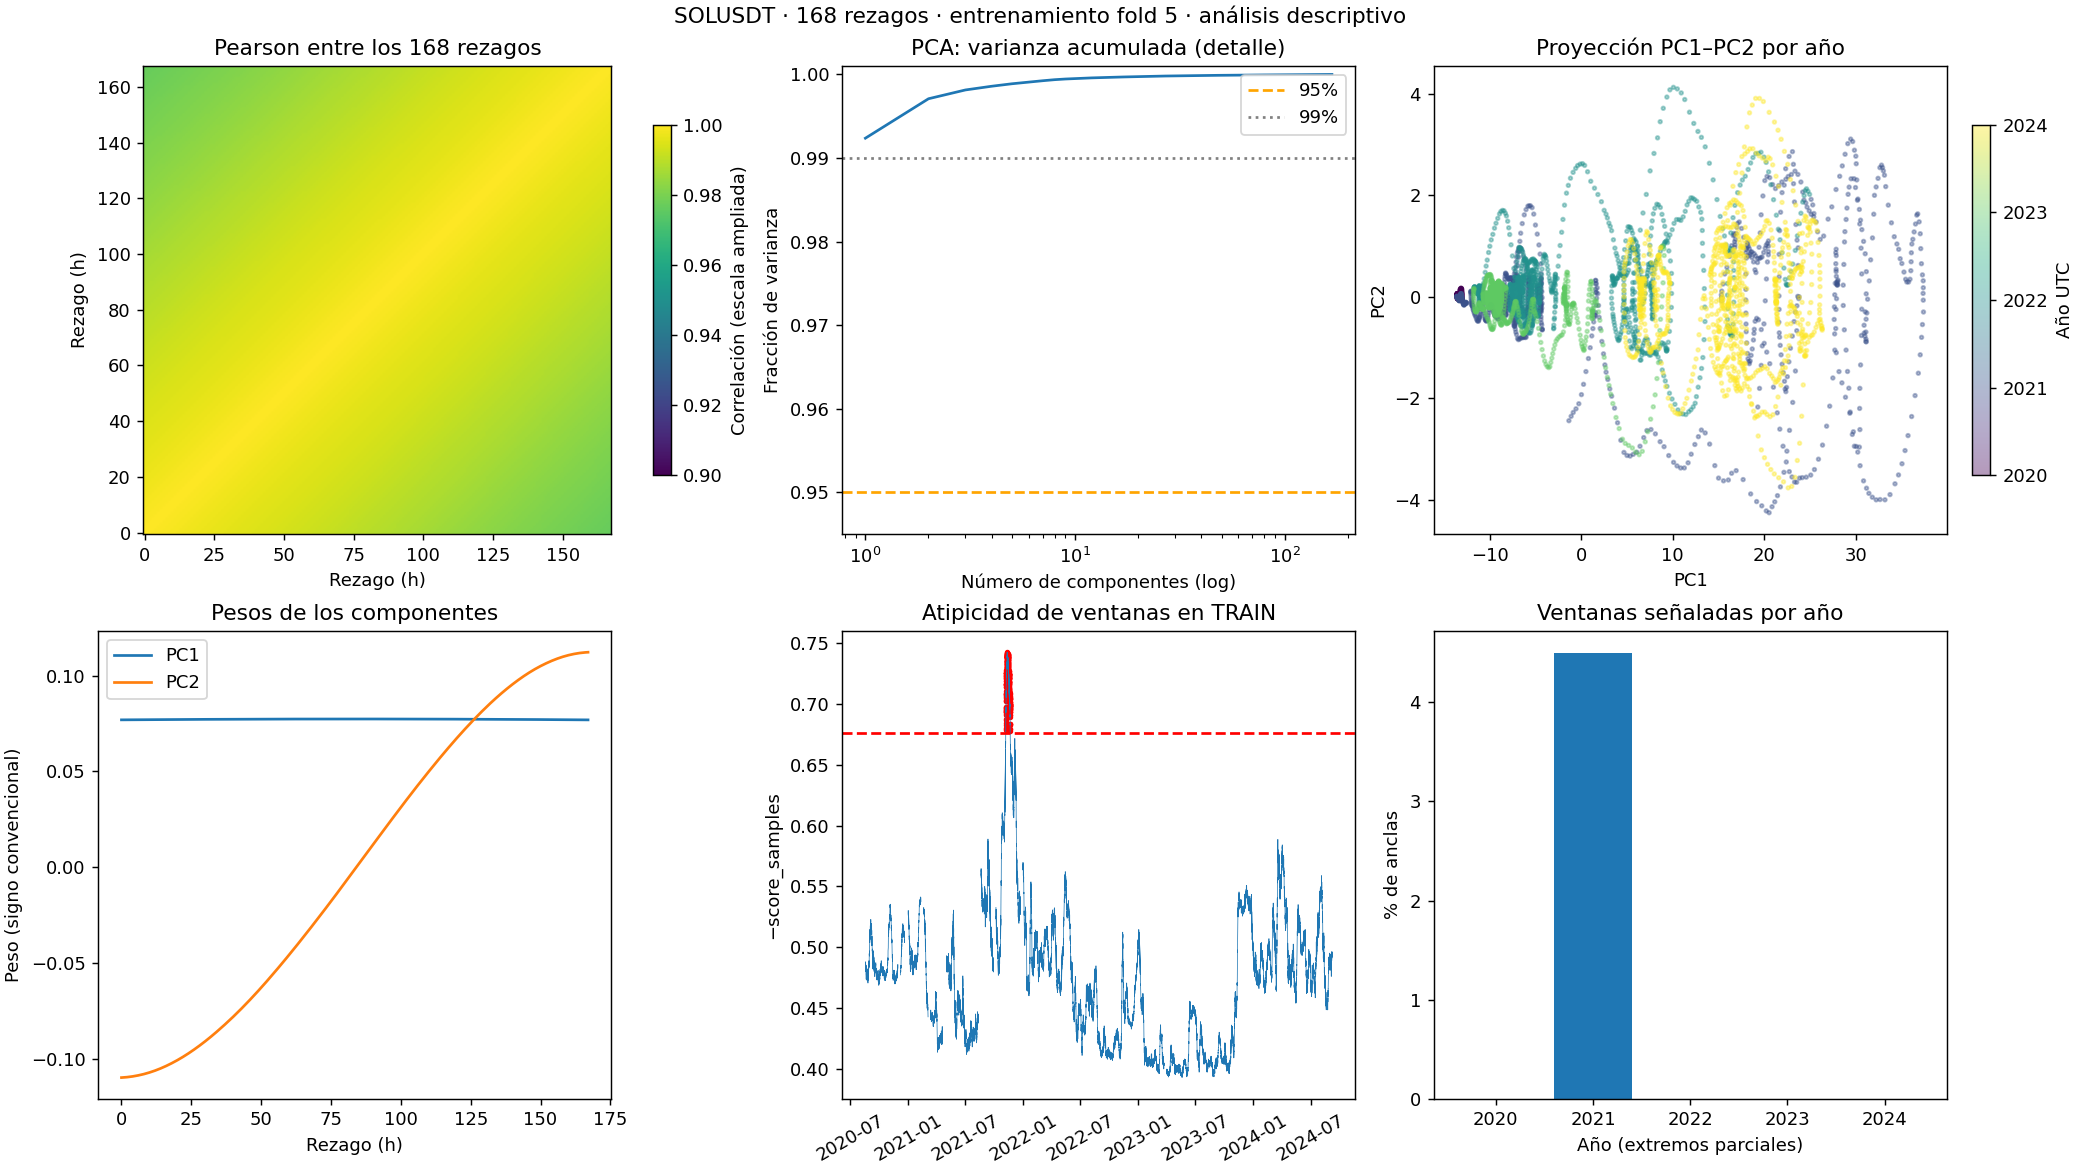

In [5]:
display(Image(filename=str(ROOT/'book/_static/figures/multivariate_SOLUSDT.png')))

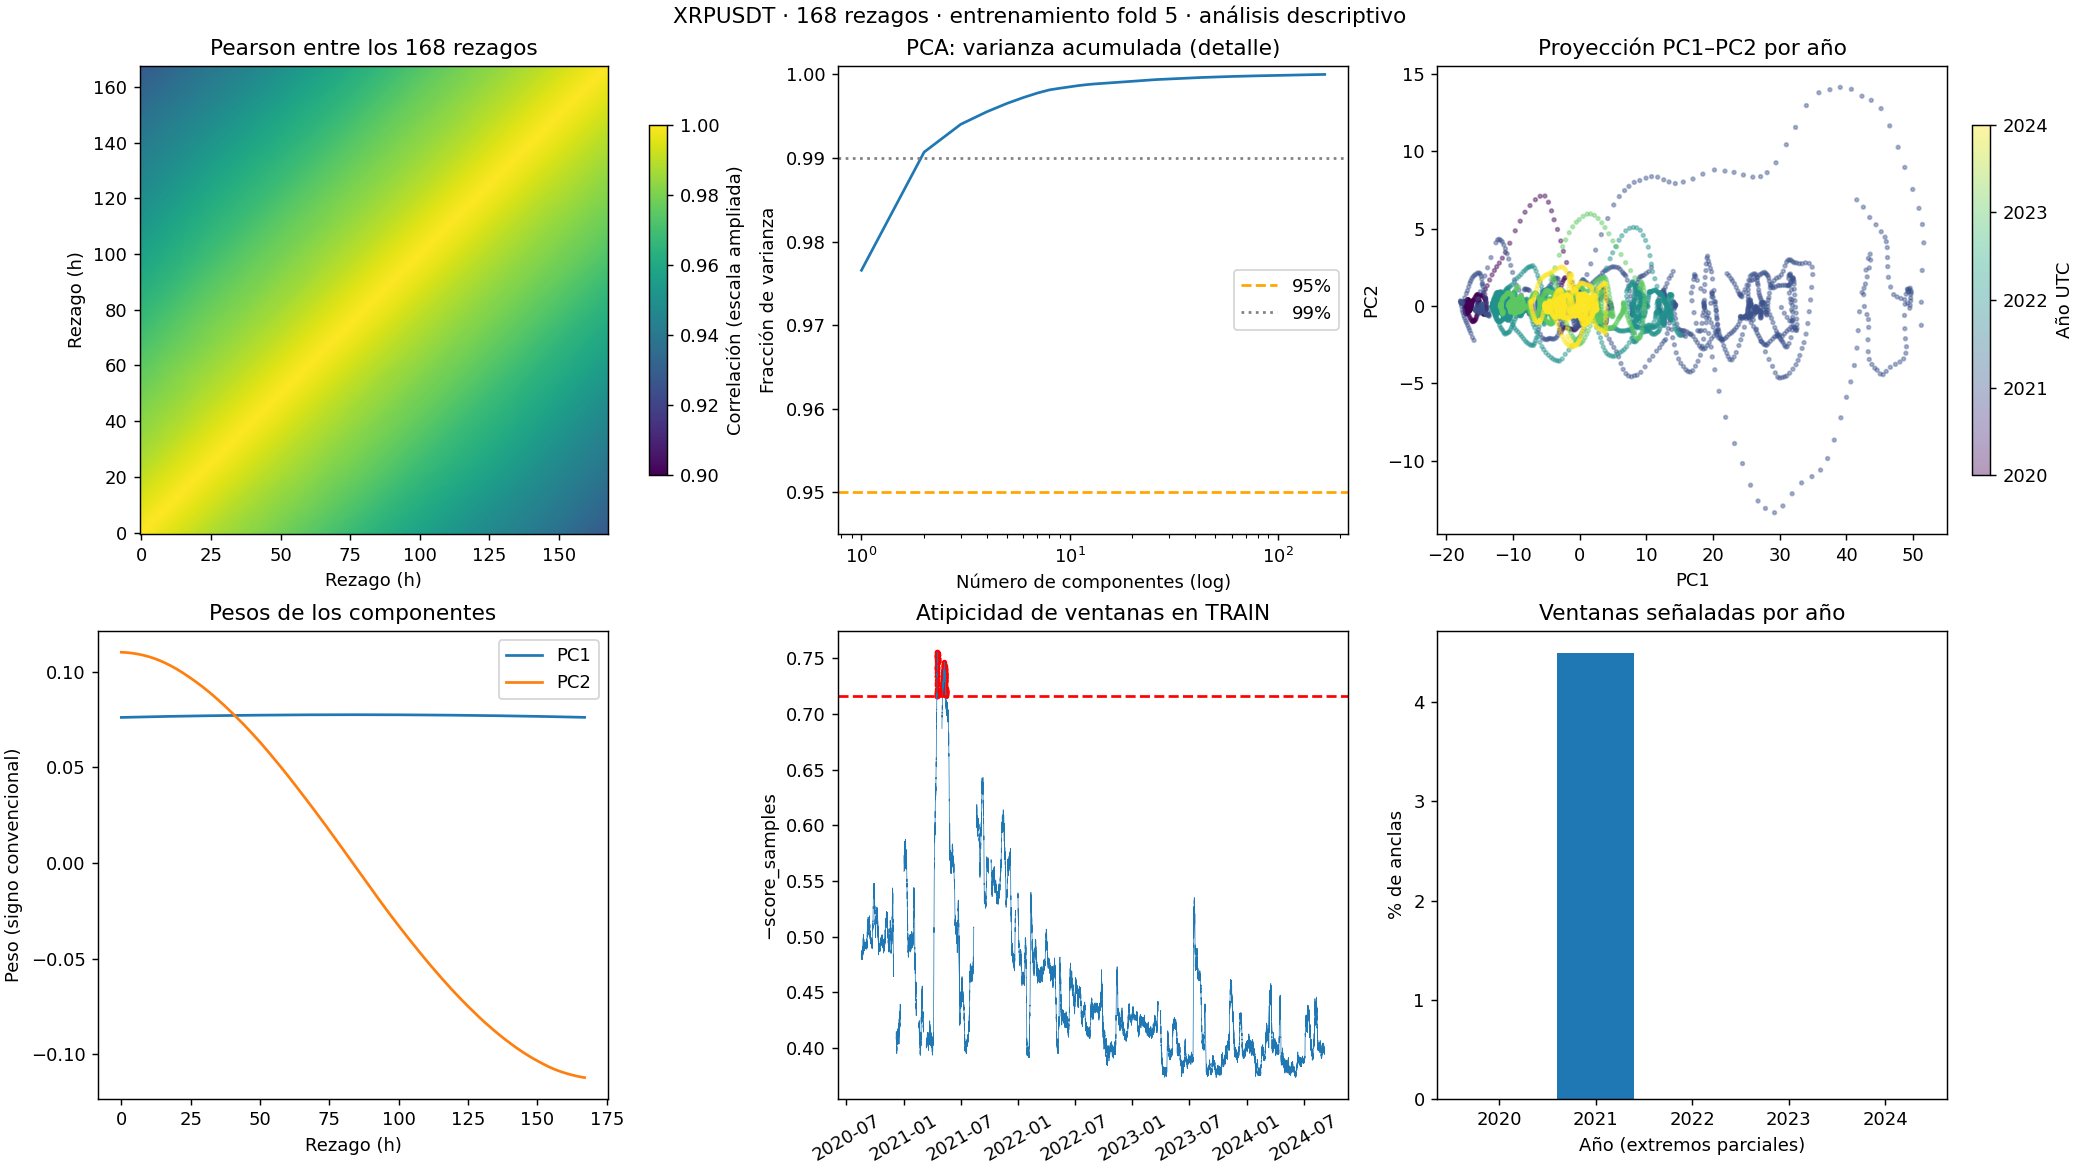

In [6]:
display(Image(filename=str(ROOT/'book/_static/figures/multivariate_XRPUSDT.png')))